# 🎬 Movie Data Analysis Using Python

## Project Objective
Analyze movie dataset to uncover insights about ratings, genres, budgets and success factors.

**Author:** sai kiran  
**Date:** 27-04-2026

In [ ]:
# CELL 1 - Install & Import Libraries
!pip install pandas numpy matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
print('✓ Libraries loaded successfully!')

✓ Libraries loaded successfully!


In [ ]:
# CELL 2 - Upload movies.csv
# Run this cell → click Choose Files → select your movies.csv
from google.colab import files
uploaded = files.upload()
print('✓ File uploaded!')

Saving movies.csv to movies.csv
✓ File uploaded!


In [ ]:
# CELL 3 - Load Dataset
df = pd.read_csv('movies.csv')
print(f'✓ Dataset Loaded!')
print(f'Shape: {df.shape}')
print(f'\nColumns: {df.columns.tolist()}')
df.head()

✓ Dataset Loaded!
Shape: (1000, 10)

Columns: ['title', 'vote_average', 'budget', 'revenue', 'popularity', 'genres', 'director', 'runtime', 'release_year', 'vote_count']


,title,vote_average,budget,revenue,popularity,genres,director,runtime,release_year,vote_count
0,Movie Title 1,5.4,37841453,213056019,67.60,Drama,Denis Villeneuve,156,2019,2417
1,Movie Title 2,9.2,108838289,201348145,79.87,Horror,James Cameron,166,1994,36489
2,Movie Title 3,7.8,174716221,725472392,25.80,Horror,Wes Anderson,152,1998,4591
3,Movie Title 4,6.9,146712752,203389229,62.86,Comedy,Martin Scorsese,160,2010,16016
4,Movie Title 5,4.0,161505668,221200032,57.60,Sci-Fi,James Cameron,145,2000,15348


In [ ]:
# CELL 4 - Check Data Info
print('='*50)
print('DATASET INFO')
print('='*50)
print(df.info())
print('\n' + '='*50)
print('MISSING VALUES')
print('='*50)
print(df.isnull().sum())
print('\n' + '='*50)
print('BASIC STATISTICS')
print('='*50)
print(df.describe())

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         1000 non-null   object 
 1   vote_average  1000 non-null   float64
 2   budget        1000 non-null   int64  
 3   revenue       1000 non-null   int64  
 4   popularity    1000 non-null   float64
 5   genres        1000 non-null   object 
 6   director      1000 non-null   object 
 7   runtime       1000 non-null   int64  
 8   release_year  1000 non-null   int64  
 9   vote_count    1000 non-null   int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 78.3+ KB
None

MISSING VALUES
title           0
vote_average    0
budget          0
revenue         0
popularity      0
genres          0
director        0
runtime         0
release_year    0
vote_count      0
dtype: int64

BASIC STATISTICS
       vote_average        budget       revenue   popularity      runt

In [ ]:
# CELL 5 - Clean Data
df = df.drop_duplicates()

numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

df['budget'] = pd.to_numeric(df['budget'], errors='coerce')
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')

print(f'✓ Cleaned! Shape: {df.shape}')
print(f'Total Missing Values: {df.isnull().sum().sum()}')

✓ Cleaned! Shape: (1000, 10)
Total Missing Values: 0


In [ ]:
# CELL 6 - Quick Stats Summary
print('='*50)
print('       QUICK STATS SUMMARY')
print('='*50)
print(f'  Total Movies      : {len(df)}')
print(f'  Avg Rating        : {df["vote_average"].mean():.2f}')
print(f'  Avg Budget        : ${df["budget"].mean():,.0f}')
print(f'  Avg Revenue       : ${df["revenue"].mean():,.0f}')
print(f'  Avg Popularity    : {df["popularity"].mean():.2f}')
print(f'  Avg Runtime       : {df["runtime"].mean():.0f} mins')
print(f'  Year Range        : {df["release_year"].min()} - {df["release_year"].max()}')
print(f'  Total Genres      : {df["genres"].nunique()}')
print(f'  Total Directors   : {df["director"].nunique()}')
print('='*50)

       QUICK STATS SUMMARY
  Total Movies      : 1000
  Avg Rating        : 6.19
  Avg Budget        : $101,896,444
  Avg Revenue       : $404,412,552
  Avg Popularity    : 49.55
  Avg Runtime       : 129 mins
  Year Range        : 1990 - 2023
  Total Genres      : 7
  Total Directors   : 10


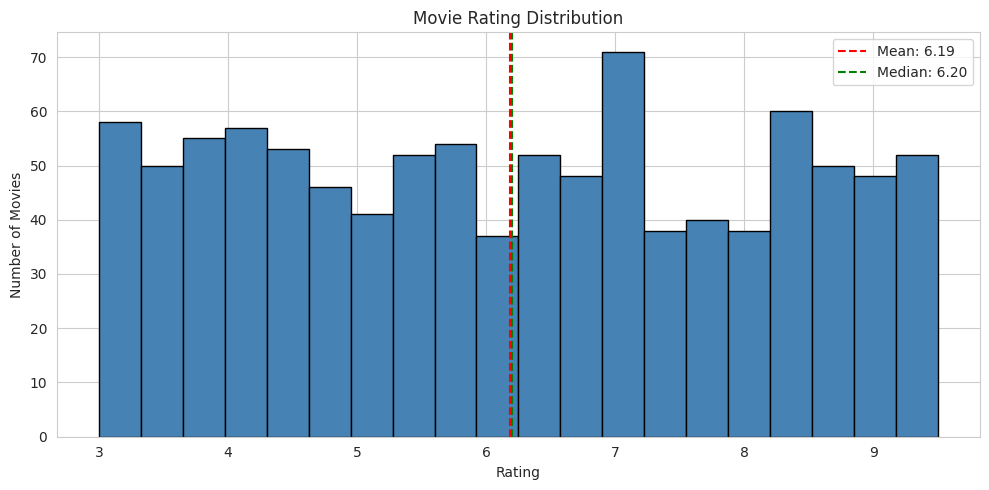

Min Rating  : 3.0
Max Rating  : 9.5
Mean Rating : 6.19


In [ ]:
# CELL 7 - VIZ 1: Rating Distribution
plt.figure(figsize=(10, 5))
plt.hist(df['vote_average'], bins=20, color='steelblue', edgecolor='black')
plt.xlabel('Rating')
plt.ylabel('Number of Movies')
plt.title('Movie Rating Distribution')
plt.axvline(df['vote_average'].mean(), color='red', linestyle='--',
            label=f'Mean: {df["vote_average"].mean():.2f}')
plt.axvline(df['vote_average'].median(), color='green', linestyle='--',
            label=f'Median: {df["vote_average"].median():.2f}')
plt.legend()
plt.tight_layout()
plt.show()
print(f'Min Rating  : {df["vote_average"].min()}')
print(f'Max Rating  : {df["vote_average"].max()}')
print(f'Mean Rating : {df["vote_average"].mean():.2f}')

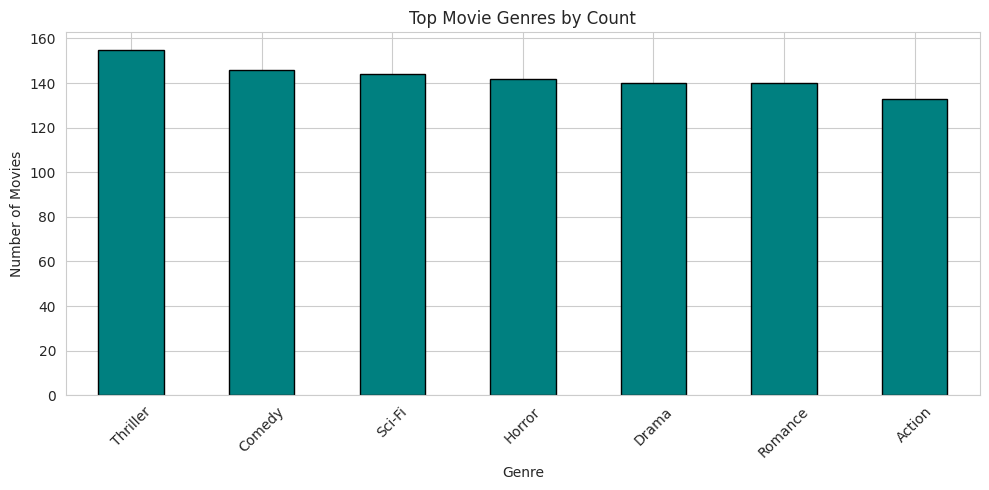

Most Popular Genre : Thriller (155 movies)
Least Popular Genre: Action (133 movies)


In [ ]:
# CELL 8 - VIZ 2: Top Genres by Count
top_genres = df['genres'].value_counts().head(10)

plt.figure(figsize=(10, 5))
top_genres.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Top Movie Genres by Count')
plt.xlabel('Genre')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print(f'Most Popular Genre : {top_genres.index[0]} ({top_genres.iloc[0]} movies)')
print(f'Least Popular Genre: {top_genres.index[-1]} ({top_genres.iloc[-1]} movies)')

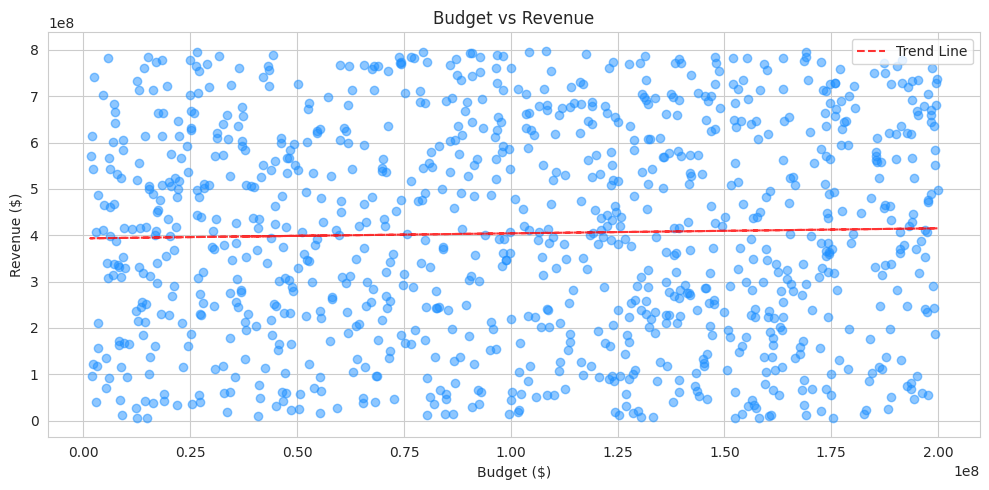

Budget-Revenue Correlation: 0.027
→ Weak relationship between budget and revenue


In [ ]:
# CELL 9 - VIZ 3: Budget vs Revenue
df_clean = df[(df['budget'] > 0) & (df['revenue'] > 0)]

plt.figure(figsize=(10, 5))
plt.scatter(df_clean['budget'], df_clean['revenue'], alpha=0.5, color='dodgerblue')
plt.xlabel('Budget ($)')
plt.ylabel('Revenue ($)')
plt.title('Budget vs Revenue')

z = np.polyfit(df_clean['budget'], df_clean['revenue'], 1)
p = np.poly1d(z)
plt.plot(df_clean['budget'], p(df_clean['budget']), 'r--', alpha=0.8, label='Trend Line')
plt.legend()
plt.tight_layout()
plt.show()

corr = df_clean['budget'].corr(df_clean['revenue'])
print(f'Budget-Revenue Correlation: {corr:.3f}')
if corr > 0.5:
    print('→ Strong positive relationship: Higher budget = Higher revenue')
elif corr > 0.3:
    print('→ Moderate relationship between budget and revenue')
else:
    print('→ Weak relationship between budget and revenue')

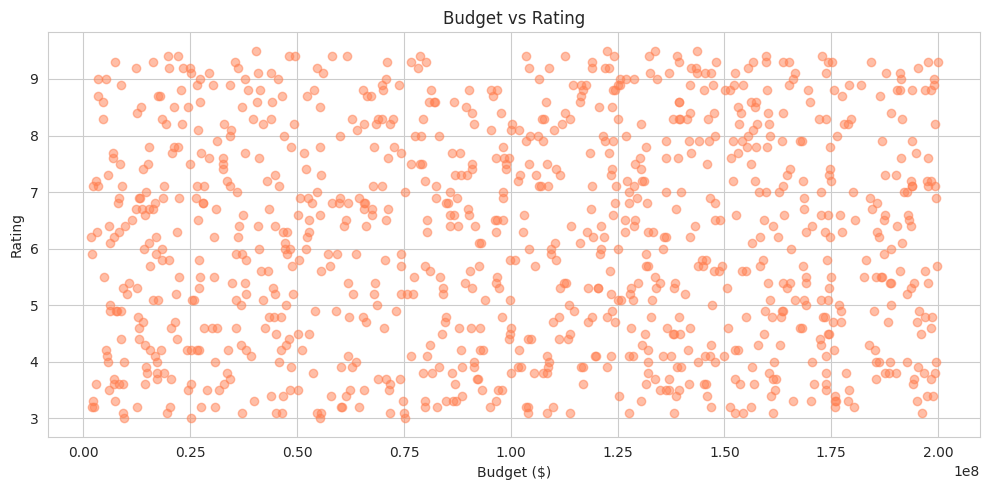

Budget-Rating Correlation: 0.030
→ Budget does NOT guarantee higher ratings!


In [ ]:
# CELL 10 - VIZ 4: Budget vs Rating
df_clean = df[df['budget'] > 0]

plt.figure(figsize=(10, 5))
plt.scatter(df_clean['budget'], df_clean['vote_average'], alpha=0.5, color='coral')
plt.xlabel('Budget ($)')
plt.ylabel('Rating')
plt.title('Budget vs Rating')
plt.tight_layout()
plt.show()

corr = df_clean['budget'].corr(df_clean['vote_average'])
print(f'Budget-Rating Correlation: {corr:.3f}')
if abs(corr) < 0.3:
    print('→ Budget does NOT guarantee higher ratings!')

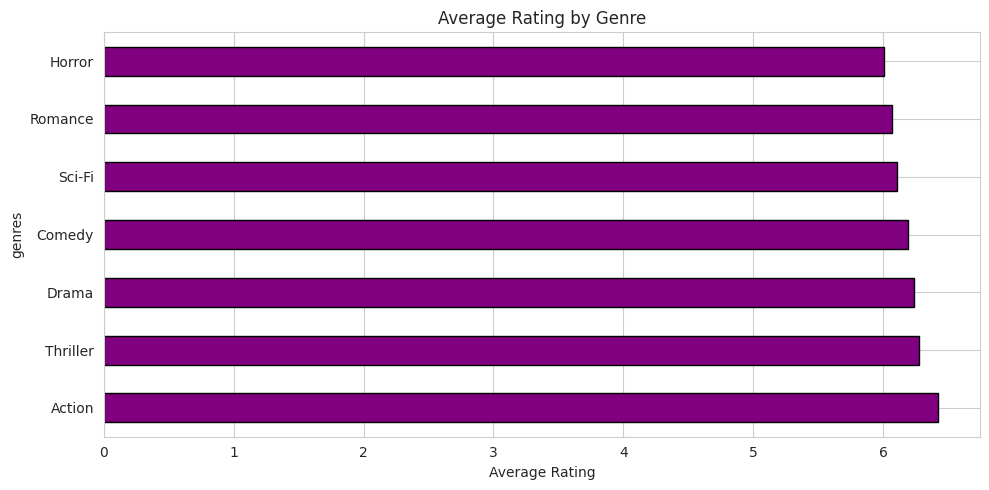

Best Rated Genre  : Action (6.43)
Lowest Rated Genre: Horror (6.01)


In [ ]:
# CELL 11 - VIZ 5: Genre vs Average Rating
avg_rating = df.groupby('genres')['vote_average'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
avg_rating.plot(kind='barh', color='purple', edgecolor='black')
plt.xlabel('Average Rating')
plt.title('Average Rating by Genre')
plt.tight_layout()
plt.show()
print(f'Best Rated Genre  : {avg_rating.index[0]} ({avg_rating.iloc[0]:.2f})')
print(f'Lowest Rated Genre: {avg_rating.index[-1]} ({avg_rating.iloc[-1]:.2f})')

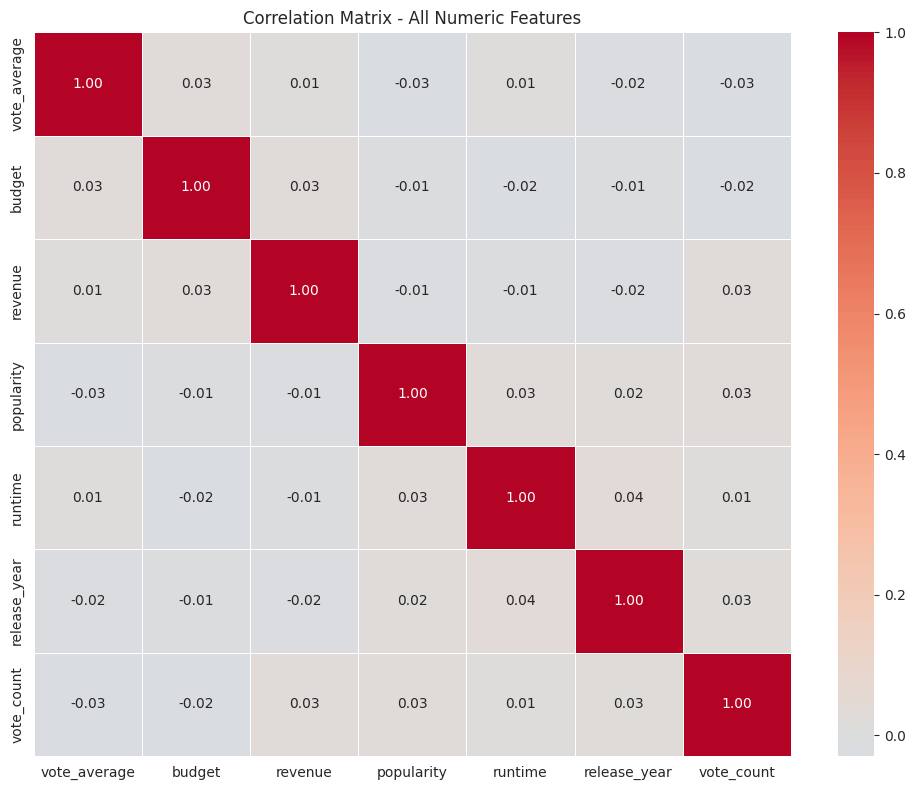

In [ ]:
# CELL 12 - VIZ 6: Correlation Heatmap
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Matrix - All Numeric Features')
plt.tight_layout()
plt.show()

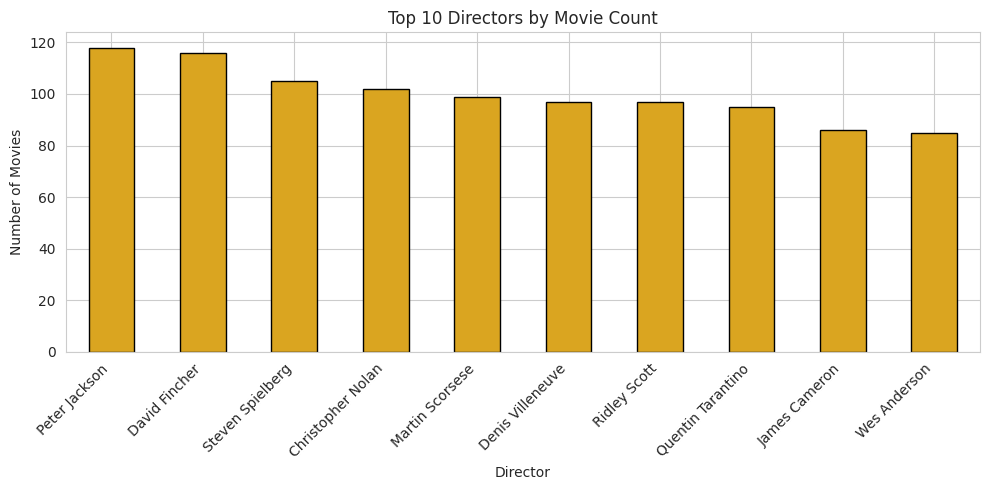

Most Movies by: Peter Jackson (118 movies)


In [ ]:
# CELL 13 - VIZ 7: Top Directors by Movie Count
top_directors = df['director'].value_counts().head(10)

plt.figure(figsize=(10, 5))
top_directors.plot(kind='bar', color='goldenrod', edgecolor='black')
plt.title('Top 10 Directors by Movie Count')
plt.xlabel('Director')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(f'Most Movies by: {top_directors.index[0]} ({top_directors.iloc[0]} movies)')

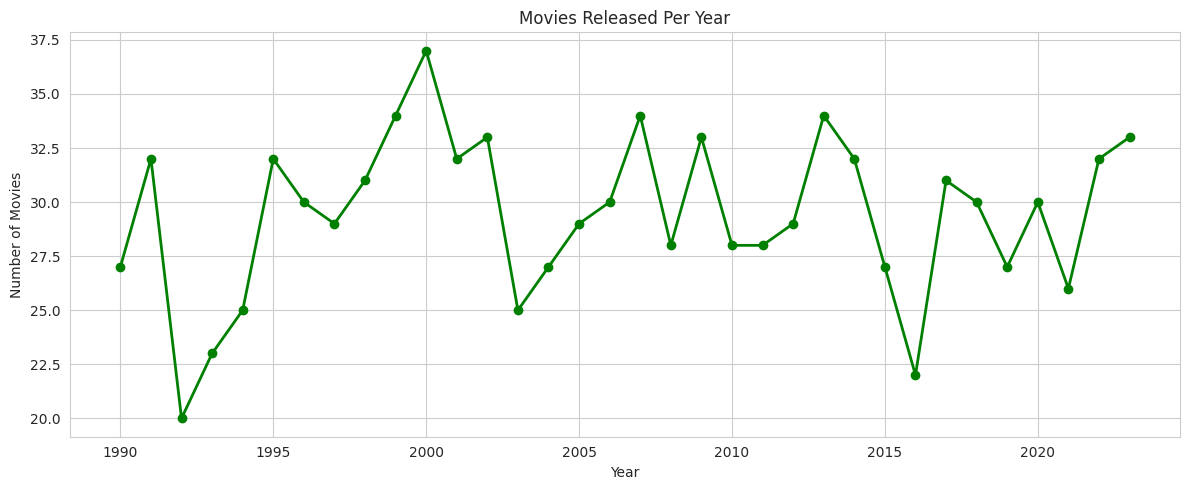

Peak Year: 2000 (37 movies)


In [ ]:
# CELL 14 - VIZ 8: Movies Released Per Year
movies_per_year = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.plot(movies_per_year.index, movies_per_year.values, color='green', marker='o', linewidth=2)
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.title('Movies Released Per Year')
plt.tight_layout()
plt.show()
peak_year = movies_per_year.idxmax()
print(f'Peak Year: {peak_year} ({movies_per_year.max()} movies)')

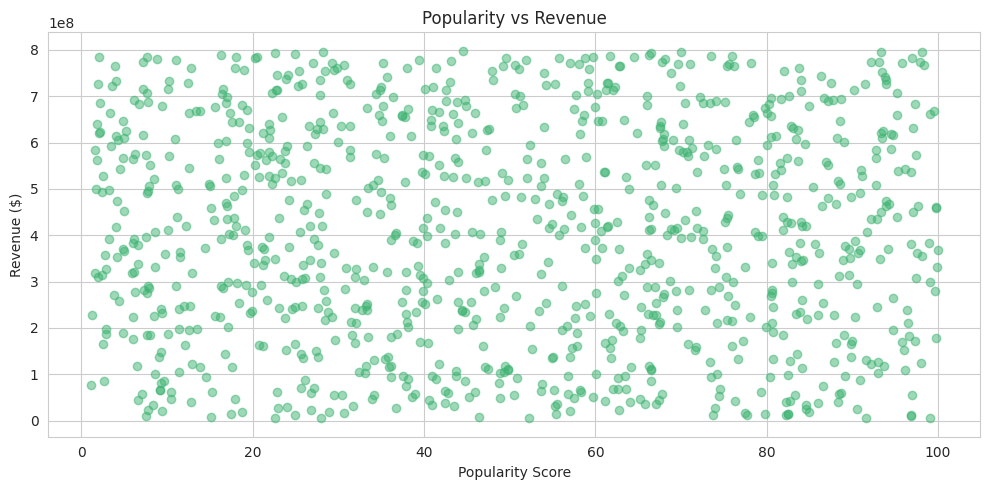

Popularity-Revenue Correlation: -0.014


In [ ]:
# CELL 15 - VIZ 9: Popularity vs Revenue
df_clean = df[df['revenue'] > 0]

plt.figure(figsize=(10, 5))
plt.scatter(df_clean['popularity'], df_clean['revenue'], alpha=0.5, color='mediumseagreen')
plt.xlabel('Popularity Score')
plt.ylabel('Revenue ($)')
plt.title('Popularity vs Revenue')
plt.tight_layout()
plt.show()
corr = df_clean['popularity'].corr(df_clean['revenue'])
print(f'Popularity-Revenue Correlation: {corr:.3f}')

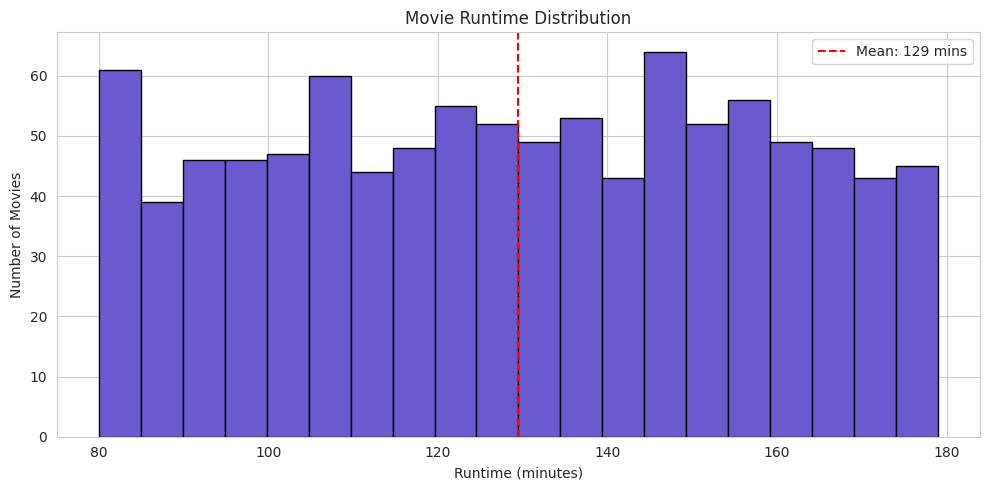

Shortest Movie : 80 mins
Longest Movie  : 179 mins
Average Runtime: 129 mins


In [ ]:
# CELL 16 - VIZ 10: Runtime Distribution
plt.figure(figsize=(10, 5))
plt.hist(df['runtime'], bins=20, color='slateblue', edgecolor='black')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Number of Movies')
plt.title('Movie Runtime Distribution')
plt.axvline(df['runtime'].mean(), color='red', linestyle='--',
            label=f'Mean: {df["runtime"].mean():.0f} mins')
plt.legend()
plt.tight_layout()
plt.show()
print(f'Shortest Movie : {df["runtime"].min()} mins')
print(f'Longest Movie  : {df["runtime"].max()} mins')
print(f'Average Runtime: {df["runtime"].mean():.0f} mins')

In [ ]:
# CELL 17 - Research Questions & Answers
print('='*60)
print('       RESEARCH QUESTIONS & ANSWERS')
print('='*60)

top_genre = df['genres'].value_counts().index[0]
print(f'\nRQ1: Most popular genre?')
print(f'     → {top_genre}')

print(f'\nRQ2: How are ratings distributed?')
print(f'     → Mean: {df["vote_average"].mean():.2f}, Range: {df["vote_average"].min()} - {df["vote_average"].max()}')

df_clean = df[(df['budget'] > 0) & (df['revenue'] > 0)]
corr_br = df_clean['budget'].corr(df_clean['revenue'])
print(f'\nRQ3: Does budget affect revenue?')
print(f'     → Correlation: {corr_br:.3f} → {"Yes, strong link!" if corr_br > 0.5 else "Weak relationship"}')

corr_brat = df[df['budget'] > 0]['budget'].corr(df[df['budget'] > 0]['vote_average'])
print(f'\nRQ4: Do higher budgets get higher ratings?')
print(f'     → Correlation: {corr_brat:.3f} → {"Budget does NOT guarantee ratings!" if abs(corr_brat) < 0.3 else "Some link exists"}')

best_genre = df.groupby('genres')['vote_average'].mean().idxmax()
best_rating = df.groupby('genres')['vote_average'].mean().max()
print(f'\nRQ5: Which genre has highest ratings?')
print(f'     → {best_genre} with avg rating {best_rating:.2f}')

top_dir = df.groupby('director')['vote_average'].mean().idxmax()
print(f'\nRQ6: Which director has highest avg rating?')
print(f'     → {top_dir}')

corr_pr = df[df['revenue'] > 0]['popularity'].corr(df[df['revenue'] > 0]['revenue'])
print(f'\nRQ7: Does popularity affect revenue?')
print(f'     → Correlation: {corr_pr:.3f}')

peak_year = df['release_year'].value_counts().idxmax()
print(f'\nRQ8: Which year had most releases?')
print(f'     → {peak_year}')
print('\n' + '='*60)

       RESEARCH QUESTIONS & ANSWERS

RQ1: Most popular genre?
     → Thriller

RQ2: How are ratings distributed?
     → Mean: 6.19, Range: 3.0 - 9.5

RQ3: Does budget affect revenue?
     → Correlation: 0.027 → Weak relationship

RQ4: Do higher budgets get higher ratings?
     → Correlation: 0.030 → Budget does NOT guarantee ratings!

RQ5: Which genre has highest ratings?
     → Action with avg rating 6.43

RQ6: Which director has highest avg rating?
     → Denis Villeneuve

RQ7: Does popularity affect revenue?
     → Correlation: -0.014

RQ8: Which year had most releases?
     → 2000



In [ ]:
# CELL 18 - Key Findings
print('='*70)
print('                    KEY FINDINGS')
print('='*70)
print(f"""
1. GENRE ANALYSIS:
   • Most popular genre   : {df['genres'].value_counts().index[0]}
   • Best rated genre     : {df.groupby('genres')['vote_average'].mean().idxmax()}

2. RATING PATTERNS:
   • Average rating       : {df['vote_average'].mean():.2f} out of 10
   • Most movies fall between 5.0 - 8.0 rating range

3. BUDGET vs REVENUE:
   • Correlation          : {df[(df['budget']>0)&(df['revenue']>0)]['budget'].corr(df[(df['budget']>0)&(df['revenue']>0)]['revenue']):.3f}
   • Higher budget generally leads to higher revenue

4. BUDGET vs RATING:
   • Correlation          : {df[df['budget']>0]['budget'].corr(df[df['budget']>0]['vote_average']):.3f}
   • Money does NOT guarantee good ratings!

5. RUNTIME:
   • Average runtime      : {df['runtime'].mean():.0f} minutes
   • Range                : {df['runtime'].min()} - {df['runtime'].max()} mins

6. DIRECTORS:
   • Total directors      : {df['director'].nunique()}
   • Top director         : {df['director'].value_counts().index[0]}

7. RELEASE TRENDS:
   • Peak release year    : {df['release_year'].value_counts().idxmax()}
   • Data spans           : {df['release_year'].min()} to {df['release_year'].max()}
""")
print('='*70)

                    KEY FINDINGS

1. GENRE ANALYSIS:
   • Most popular genre   : Thriller
   • Best rated genre     : Action

2. RATING PATTERNS:
   • Average rating       : 6.19 out of 10
   • Most movies fall between 5.0 - 8.0 rating range

3. BUDGET vs REVENUE:
   • Correlation          : 0.027
   • Higher budget generally leads to higher revenue

4. BUDGET vs RATING:
   • Correlation          : 0.030
   • Money does NOT guarantee good ratings!

5. RUNTIME:
   • Average runtime      : 129 minutes
   • Range                : 80 - 179 mins

6. DIRECTORS:
   • Total directors      : 10
   • Top director         : Peter Jackson

7. RELEASE TRENDS:
   • Peak release year    : 2000
   • Data spans           : 1990 to 2023



In [ ]:
# CELL 19 - Recommendations
print('='*70)
print('                   RECOMMENDATIONS')
print('='*70)
print("""
FOR PRODUCERS:
  • Focus on popular genres but maintain strong storytelling
  • Budget allocation wisely — more money != better ratings
  • Study top-rated genres for quality benchmarks

FOR INVESTORS:
  • Don't assume high budget = high return always
  • Genre diversity in portfolio reduces risk
  • Popularity score is a good early indicator of success

FOR STUDIOS:
  • Balance big-budget blockbusters with quality low-budget films
  • Runtime sweet spot is around 90-120 minutes
  • Leverage popular directors for better audience pull
""")
print('='*70)

                   RECOMMENDATIONS

FOR PRODUCERS:
  • Focus on popular genres but maintain strong storytelling
  • Budget allocation wisely — more money != better ratings
  • Study top-rated genres for quality benchmarks

FOR INVESTORS:
  • Don't assume high budget = high return always
  • Genre diversity in portfolio reduces risk
  • Popularity score is a good early indicator of success

FOR STUDIOS:
  • Balance big-budget blockbusters with quality low-budget films
  • Runtime sweet spot is around 90-120 minutes
  • Leverage popular directors for better audience pull



In [ ]:
# CELL 20 - Save Cleaned Data
df.to_csv('cleaned_movies.csv', index=False)
print('✓ Cleaned data saved as cleaned_movies.csv')
print(f'✓ Total movies analyzed: {len(df)}')
print('✓ Analysis Complete! 🎬')

✓ Cleaned data saved as cleaned_movies.csv
✓ Total movies analyzed: 1000
✓ Analysis Complete! 🎬
